# Embedding Benchmark 

Benchmarks the SentenceTransformer embedder used in `backend/app/rag/embedder.py`. First load may download models.


## What this benchmarks
- **Model load time**
- **Per-doc latency vs text length** (tiny→XL)
- **Query latency** (min/avg/max)
- **Batch latency** (throughput view)
- **Multi-model comparison** (swap models)



## Setup paths and cache
Adds repo root to `sys.path` and pins HF cache to `.hf_cache` locally.


In [1]:
import os, sys, time
from pathlib import Path

repo_root = Path().resolve().parent
sys.path.append(str(repo_root))  # so 'backend' package is importable

os.environ.setdefault('HF_HOME', str(repo_root / '.hf_cache'))
os.environ.setdefault('TRANSFORMERS_CACHE', str(repo_root / '.hf_cache'))

print('Repo root:', repo_root)
print('Python path contains repo root:', str(repo_root) in sys.path)


Repo root: /home/rayene/DCL/Repos/AI-Assistant-for-Technical-Knowledge-Management
Python path contains repo root: True


## Load the embedder and measure model init
Creates the embedder via `get_embedder()`, forces model load, and reports device + dimension.


In [2]:
from backend.app.rag.embedder import get_embedder

t0 = time.perf_counter()
embedder = get_embedder()
model = embedder._load_model()
t_load = time.perf_counter() - t0

print('Model:', model.__class__.__name__)
print('Device:', getattr(model, 'device', 'unknown'))
print('Embedding dimension:', embedder.get_dimension())
print(f'Initial load time: {t_load:.2f}s')


/home/rayene/DCL/Repos/AI-Assistant-for-Technical-Knowledge-Management/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/rayene/DCL/Repos/AI-Assistant-for-Technical-Knowledge-Management/.venv/lib/python3.12/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
A new version of the following files was downloaded from https://huggingface.co/jinaai/jina-embeddings-v3:
- custom_st.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/jinaai/xlm-roberta-flash-implementation:
- configuration_xlm_

Model: SentenceTransformer
Device: cuda:0
Embedding dimension: 1024
Initial load time: 4.38s


## Build synthetic texts for length and batch testing
Toggle `USE_XL` to include/exclude the very large text; disabling it keeps runs fast and light on RAM.


In [3]:
USE_XL = True # set True to include the heavy XL payload

def repeat(base: str, n: int) -> str:
    return " ".join([base] * n)

texts = {
    'tiny': "Hello embeddings.",
    'short': "Simple test sentence about vector embeddings.",
    'medium': repeat('Paragraph about retrieval augmented generation and chroma storage.', 20),
    'long': repeat('Technical discussion about microservices, tracing, and observability in complex systems.', 200),
}

if USE_XL:
    texts['xl'] = repeat('Deep dive into distributed tracing, queue backpressure, retries, and SLA/SLO management across services.', 600)

doc_labels = list(texts.keys())
docs = [texts[k] for k in doc_labels]
doc_lengths = [len(t) for t in docs]

batch_payloads = {
    'short x10': [texts['short']] * 10,
    'medium x5': [texts['medium']] * 5,
    'long x3': [texts['long']] * 3,
}
if USE_XL:
    batch_payloads['xl x2'] = [texts['xl']] * 2

print('Doc lengths:', dict(zip(doc_labels, doc_lengths)))
print('Batch payload sizes:', {k: len(v) for k, v in batch_payloads.items()})



Doc lengths: {'tiny': 17, 'short': 45, 'medium': 1339, 'long': 17799, 'xl': 62999}
Batch payload sizes: {'short x10': 10, 'medium x5': 5, 'long x3': 3, 'xl x2': 2}


## Helper timers
- `bench_embed_docs`: per-doc latency.
- `bench_query`: single-query latency stats.
- `bench_batches`: batch latency.
Axes: per-doc, per-query, batch.


In [4]:
def bench_embed_docs(texts, labels=None):
    results = []
    for idx, t in enumerate(texts):
        label = labels[idx] if labels and idx < len(labels) else f'doc_{idx}'
        t0 = time.perf_counter()
        _ = embedder.embed_documents([t])
        dt = time.perf_counter() - t0
        results.append((label, dt))
    return results

def bench_query(query: str, repeats: int = 10):
    timings = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        _ = embedder.embed_query(query)
        timings.append(time.perf_counter() - t0)
    return min(timings), sum(timings)/len(timings), max(timings)

def bench_batches(batch_map):
    results = []
    for name, payload in batch_map.items():
        t0 = time.perf_counter()
        _ = embedder.embed_documents(payload)
        dt = time.perf_counter() - t0
        results.append((name, len(payload), dt))
    return results



## Run the benchmarks
Per-doc, per-query, batch timings. Stores results for plotting.


In [5]:
doc_results = bench_embed_docs(docs, labels=doc_labels)
for label, t in doc_results:
    print(f'{label:>6}: {t:.3f}s')

qmin, qavg, qmax = bench_query('Why use Jina embeddings for RAG?', repeats=10)
print(f'Query latency -> avg: {qavg:.3f}s | min: {qmin:.3f}s | max: {qmax:.3f}s')

batch_results = bench_batches(batch_payloads)
for name, size, dt in batch_results:
    print(f'Batch {name:>10} (size={size}): {dt:.3f}s')



  tiny: 0.442s
 short: 0.033s
medium: 0.036s
  long: 0.345s
    xl: 1.987s
Query latency -> avg: 0.030s | min: 0.026s | max: 0.036s
Batch  short x10 (size=10): 0.030s
Batch  medium x5 (size=5): 0.086s
Batch    long x3 (size=3): 1.520s
Batch      xl x2 (size=2): 181.193s


## Plots: latency vs length and batch size
Uses current model’s results.


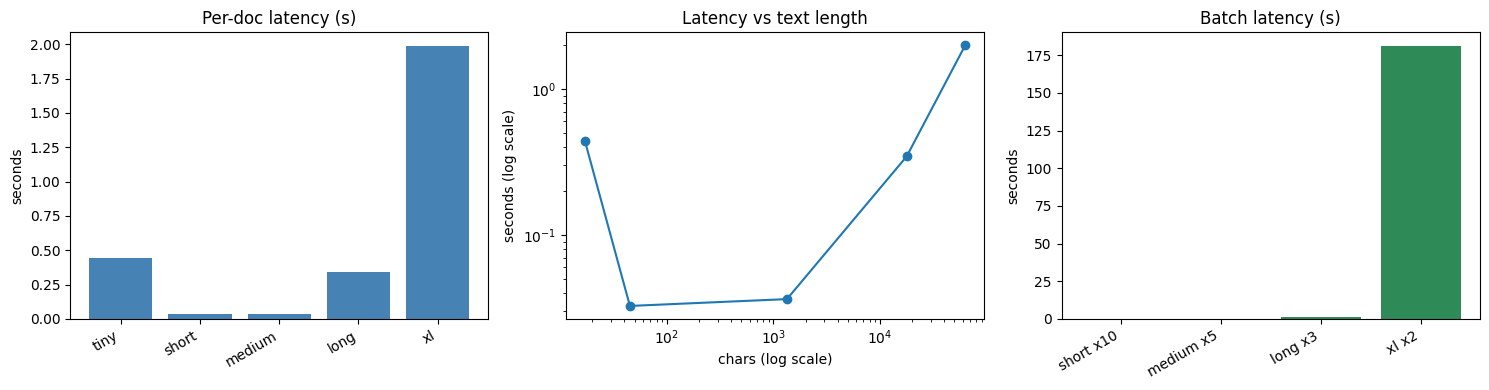

Query latency (avg/min/max): 0.030s / 0.026s / 0.036s


In [6]:
import matplotlib.pyplot as plt
import numpy as np

labels = [r[0] for r in doc_results]
doc_times = [r[1] for r in doc_results]
lengths = doc_lengths

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(range(len(labels)), doc_times, color='steelblue')
axes[0].set_xticks(range(len(labels)))
axes[0].set_xticklabels(labels, rotation=30, ha='right')
axes[0].set_title('Per-doc latency (s)')
axes[0].set_ylabel('seconds')

axes[1].plot(lengths, doc_times, marker='o')
axes[1].set_title('Latency vs text length')
axes[1].set_xlabel('chars (log scale)')
axes[1].set_ylabel('seconds (log scale)')
axes[1].set_xscale('log')
axes[1].set_yscale('log')

batch_names = [r[0] for r in batch_results]
batch_times = [r[2] for r in batch_results]
axes[2].bar(range(len(batch_names)), batch_times, color='seagreen')
axes[2].set_xticks(range(len(batch_names)))
axes[2].set_xticklabels(batch_names, rotation=30, ha='right')
axes[2].set_title('Batch latency (s)')
axes[2].set_ylabel('seconds')

plt.tight_layout()
plt.show()

print(f'Query latency (avg/min/max): {qavg:.3f}s / {qmin:.3f}s / {qmax:.3f}s')



## Model comparison (multi-model)
Runs full benchmark per model and stores metrics for plotting/reporting. Edit `MODELS` to change models.


In [7]:
import importlib, os, time, gc
try:
    import torch
except ImportError:
    torch = None

MODELS = [
    'jinaai/jina-embeddings-v3',
    'sentence-transformers/all-MiniLM-L6-v2',
    'intfloat/e5-base-v2',
]

results_per_model = []

def run_model(model_name: str):
    os.environ['EMBEDDING_MODEL'] = model_name
    import backend.app.config as conf
    import backend.app.rag.embedder as emb
    importlib.reload(conf)
    importlib.reload(emb)
    t0 = time.perf_counter()
    embedder_local = emb.get_embedder()
    model = embedder_local._load_model()
    load_time = time.perf_counter() - t0

    doc_runs = bench_embed_docs(docs, labels=doc_labels)
    batch_runs = bench_batches(batch_payloads)
    qmin_l, qavg_l, qmax_l = bench_query('Why use Jina embeddings for RAG?', repeats=5)

    results_per_model.append({
        'model': model_name,
        'device': getattr(model, 'device', 'unknown'),
        'dim': embedder_local.get_dimension(),
        'load_time': load_time,
        'doc_times': {lbl: t for lbl, t in doc_runs},
        'batch_times': {name: dt for name, _, dt in batch_runs},
        'query': {'min': qmin_l, 'avg': qavg_l, 'max': qmax_l},
    })

    print(f"=== {model_name} ===")
    print(f"Load time: {load_time:.3f}s | Device: {getattr(model, 'device', 'unknown')} | Dim: {embedder_local.get_dimension()}")
    print('Per-doc:', ', '.join([f"{lbl}={t:.3f}s" for lbl, t in doc_runs]))
    print(f"Query   : avg={qavg_l:.3f}s / min={qmin_l:.3f}s / max={qmax_l:.3f}s")
    print('Batches :', ', '.join([f"{name}={dt:.3f}s" for name, _, dt in batch_runs]))

    # Free memory for next model
    del embedder_local, model
    gc.collect()
    if torch is not None and torch.cuda.is_available():
        torch.cuda.empty_cache()

for m in MODELS:
    run_model(m)



A new version of the following files was downloaded from https://huggingface.co/jinaai/jina-embeddings-v3:
- custom_st.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/jinaai/xlm-roberta-flash-implementation:
- configuration_xlm_roberta.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/jinaai/xlm-roberta-flash-implementation:
- modeling_lora.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention 

=== jinaai/jina-embeddings-v3 ===
Load time: 4.302s | Device: cuda:0 | Dim: 1024
Per-doc: tiny=0.034s, short=0.028s, medium=0.029s, long=0.490s, xl=40.412s
Query   : avg=0.027s / min=0.025s / max=0.029s
Batches : short x10=0.033s, medium x5=0.069s, long x3=1.342s, xl x2=192.986s


A new version of the following files was downloaded from https://huggingface.co/jinaai/jina-embeddings-v3:
- custom_st.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/jinaai/xlm-roberta-flash-implementation:
- configuration_xlm_roberta.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/jinaai/xlm-roberta-flash-implementation:
- modeling_lora.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention 

=== sentence-transformers/all-MiniLM-L6-v2 ===
Load time: 4.047s | Device: cuda:0 | Dim: 1024
Per-doc: tiny=0.027s, short=0.025s, medium=0.028s, long=0.314s, xl=4.552s
Query   : avg=0.027s / min=0.024s / max=0.032s
Batches : short x10=0.028s, medium x5=0.044s, long x3=1.049s, xl x2=109.823s


A new version of the following files was downloaded from https://huggingface.co/jinaai/jina-embeddings-v3:
- custom_st.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/jinaai/xlm-roberta-flash-implementation:
- configuration_xlm_roberta.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/jinaai/xlm-roberta-flash-implementation:
- modeling_lora.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention 

=== intfloat/e5-base-v2 ===
Load time: 4.205s | Device: cuda:0 | Dim: 1024
Per-doc: tiny=0.026s, short=0.025s, medium=0.028s, long=0.301s, xl=4.365s
Query   : avg=0.029s / min=0.022s / max=0.043s
Batches : short x10=0.029s, medium x5=0.048s, long x3=0.953s, xl x2=111.332s


## Plots: multi-model comparisons
Load time, per-doc latency by size, query avg, and batch latency across models.


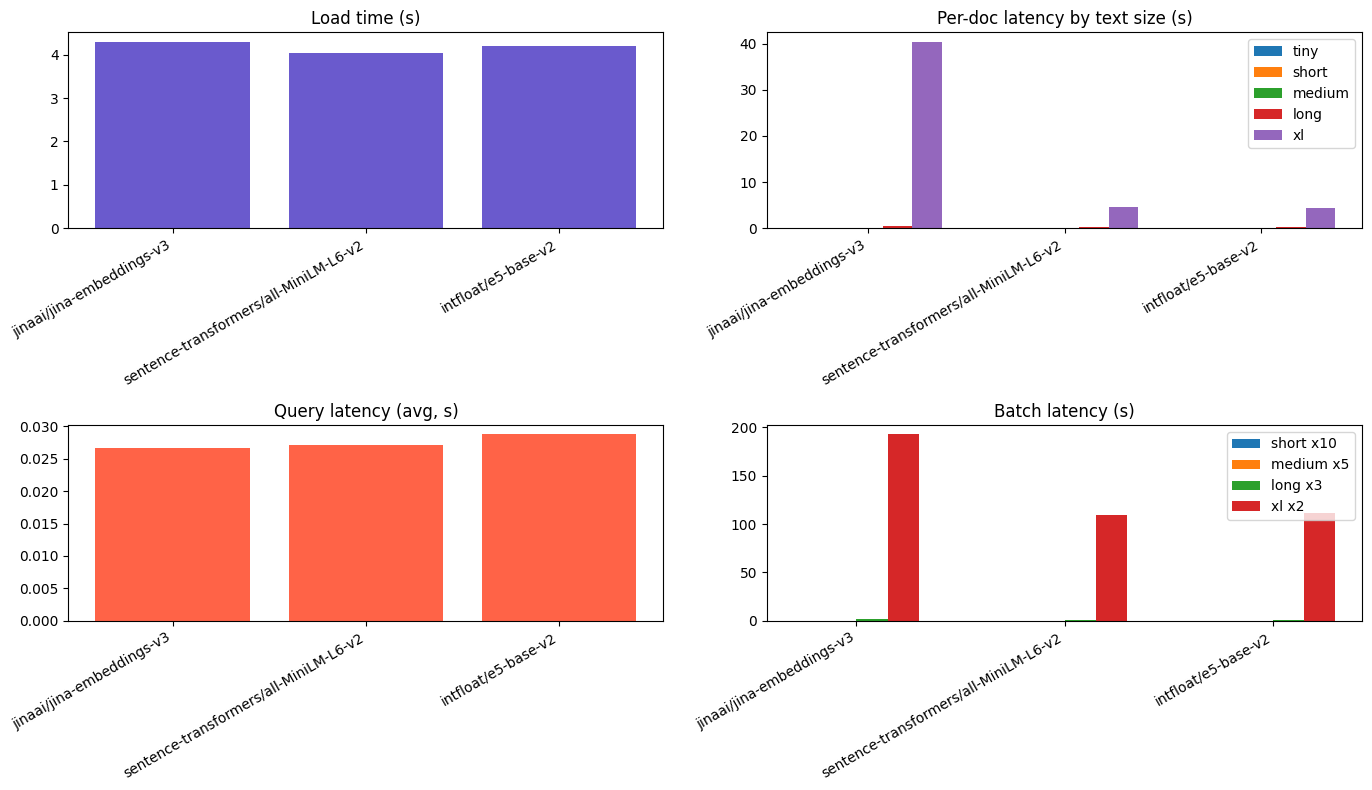

In [8]:
import matplotlib.pyplot as plt
import numpy as np

if not results_per_model:
    print('No model results yet. Run the model comparison cell first.')
else:
    models = [r['model'] for r in results_per_model]
    load_times = [r['load_time'] for r in results_per_model]

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    axes[0,0].bar(range(len(models)), load_times, color='slateblue')
    axes[0,0].set_xticks(range(len(models)))
    axes[0,0].set_xticklabels(models, rotation=30, ha='right')
    axes[0,0].set_title('Load time (s)')

    x = np.arange(len(models))
    width = 0.15
    for i, lbl in enumerate(doc_labels):
        vals = [r['doc_times'].get(lbl, np.nan) for r in results_per_model]
        axes[0,1].bar(x + i*width, vals, width, label=lbl)
    axes[0,1].set_xticks(x + width*(len(doc_labels)-1)/2)
    axes[0,1].set_xticklabels(models, rotation=30, ha='right')
    axes[0,1].set_title('Per-doc latency by text size (s)')
    axes[0,1].legend()

    q_avgs = [r['query']['avg'] for r in results_per_model]
    axes[1,0].bar(range(len(models)), q_avgs, color='tomato')
    axes[1,0].set_xticks(range(len(models)))
    axes[1,0].set_xticklabels(models, rotation=30, ha='right')
    axes[1,0].set_title('Query latency (avg, s)')

    batch_keys = list(batch_payloads.keys())
    width_b = 0.15
    for i, bkey in enumerate(batch_keys):
        vals = [r['batch_times'].get(bkey, np.nan) for r in results_per_model]
        axes[1,1].bar(x + i*width_b, vals, width_b, label=bkey)
    axes[1,1].set_xticks(x + width_b*(len(batch_keys)-1)/2)
    axes[1,1].set_xticklabels(models, rotation=30, ha='right')
    axes[1,1].set_title('Batch latency (s)')
    axes[1,1].legend()

    plt.tight_layout()
    plt.show()



## Textual report
Summarizes each model’s load time, per-doc latency (tiny→XL), query stats, and batch latency.


In [9]:
if not results_per_model:
    print('No model results yet. Run the model comparison cell first.')
else:
    for r in results_per_model:
        print(f"=== {r['model']} ===")
        print(f"Device: {r['device']} | Dim: {r['dim']} | Load: {r['load_time']:.3f}s")
        print('Per-doc:', ', '.join([f"{k}={v:.3f}s" for k,v in r['doc_times'].items()]))
        q = r['query']
        print(f"Query  : avg={q['avg']:.3f}s / min={q['min']:.3f}s / max={q['max']:.3f}s")
        print('Batches:', ', '.join([f"{k}={v:.3f}s" for k,v in r['batch_times'].items()]))



=== jinaai/jina-embeddings-v3 ===
Device: cuda:0 | Dim: 1024 | Load: 4.302s
Per-doc: tiny=0.034s, short=0.028s, medium=0.029s, long=0.490s, xl=40.412s
Query  : avg=0.027s / min=0.025s / max=0.029s
Batches: short x10=0.033s, medium x5=0.069s, long x3=1.342s, xl x2=192.986s
=== sentence-transformers/all-MiniLM-L6-v2 ===
Device: cuda:0 | Dim: 1024 | Load: 4.047s
Per-doc: tiny=0.027s, short=0.025s, medium=0.028s, long=0.314s, xl=4.552s
Query  : avg=0.027s / min=0.024s / max=0.032s
Batches: short x10=0.028s, medium x5=0.044s, long x3=1.049s, xl x2=109.823s
=== intfloat/e5-base-v2 ===
Device: cuda:0 | Dim: 1024 | Load: 4.205s
Per-doc: tiny=0.026s, short=0.025s, medium=0.028s, long=0.301s, xl=4.365s
Query  : avg=0.029s / min=0.022s / max=0.043s
Batches: short x10=0.029s, medium x5=0.048s, long x3=0.953s, xl x2=111.332s
